<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/NLP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/nlp_dataset.csv")

In [ ]:
df

,id,text
0,1,I love Natural Language Processing! It is amaz...
1,2,NLP helps computers understand human language.
2,3,Python is widely used for machine learning and...
3,4,Chatbots are built using NLP techniques.
4,5,"Text preprocessing includes tokenization, stem..."
5,6,Machine learning models require clean data.
6,7,NLTK and spaCy are popular NLP libraries.
7,8,"Data science combines statistics, programming,..."
8,9,Artificial Intelligence is transforming indust...
9,10,Deep learning models work well with large data...


In [ ]:
df.columns

Index(['id', 'text'], dtype='object')

# Univariate Analysis

<Axes: xlabel='id'>

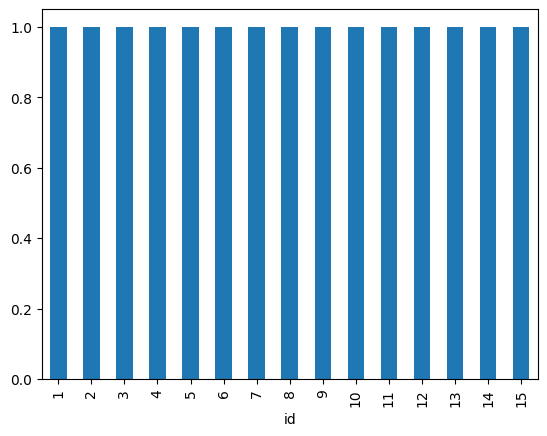

In [ ]:
#distribution of the target column
df["id"].value_counts().plot(kind="bar")

In [ ]:
df["char_count"]=df["text"].str.len()

In [ ]:
df

,id,text,char_count
0,1,I love Natural Language Processing! It is amaz...,50
1,2,NLP helps computers understand human language.,46
2,3,Python is widely used for machine learning and...,50
3,4,Chatbots are built using NLP techniques.,40
4,5,"Text preprocessing includes tokenization, stem...",70
5,6,Machine learning models require clean data.,43
6,7,NLTK and spaCy are popular NLP libraries.,41
7,8,"Data science combines statistics, programming,...",68
8,9,Artificial Intelligence is transforming indust...,51
9,10,Deep learning models work well with large data...,51


/tmp/ipykernel_6503/1367858664.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["char_count"])


<Axes: xlabel='char_count', ylabel='Density'>

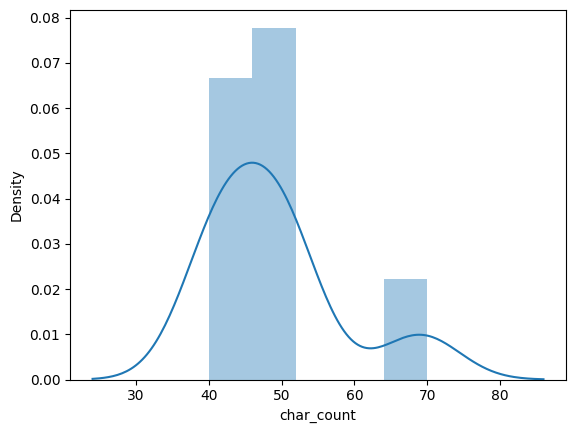

In [ ]:
sns.distplot(df["char_count"])

In [ ]:
import scipy.stats as stats

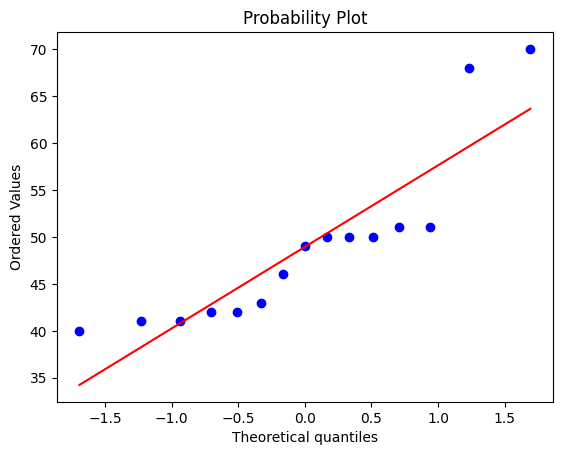

In [ ]:
stats.probplot(df["char_count"],dist="norm",plot=plt)
plt.show()

In [ ]:
spam_char_count=df[df["id"]=="spam"]["char_count"]

In [ ]:
ham_char_count=df[df["id"]=="ham"]["char_count"]

In [ ]:
#estimate avg char count for spam and ham--->CLT
def estimate_CLT(data,sample_size,no_of_samples):
    mean_lst=[]
    for i in range(no_of_samples):
        smaples=np.random.choice(data,size=sample_size)
        mean_lst.append(np.mean(smaples))
    mean_Array=np.array(mean_lst)
    return np.mean(mean_Array)

In [ ]:
sample_size=30
no_of_samples=1000
data=df["char_count"]
avg_spam_char=estimate_CLT(data,sample_size,no_of_samples)

In [ ]:
avg_spam_char

np.float64(48.881433333333334)

In [ ]:
avg_ham_char=estimate_CLT(df["char_count"],30,1000)

In [ ]:
avg_ham_char


np.float64(48.87676666666666)

In [ ]:
df.head()

,id,text,char_count
0,1,I love Natural Language Processing! It is amaz...,50
1,2,NLP helps computers understand human language.,46
2,3,Python is widely used for machine learning and...,50
3,4,Chatbots are built using NLP techniques.,40
4,5,"Text preprocessing includes tokenization, stem...",70


In [ ]:
df["word_count"]=df["text"].str.split().apply(len)

In [ ]:
df

,id,text,char_count,word_count
0,1,I love Natural Language Processing! It is amaz...,50,8
1,2,NLP helps computers understand human language.,46,6
2,3,Python is widely used for machine learning and...,50,9
3,4,Chatbots are built using NLP techniques.,40,6
4,5,"Text preprocessing includes tokenization, stem...",70,7
5,6,Machine learning models require clean data.,43,6
6,7,NLTK and spaCy are popular NLP libraries.,41,7
7,8,"Data science combines statistics, programming,...",68,8
8,9,Artificial Intelligence is transforming indust...,51,5
9,10,Deep learning models work well with large data...,51,8


/tmp/ipykernel_6503/1182839749.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["word_count"])


<Axes: xlabel='word_count', ylabel='Density'>

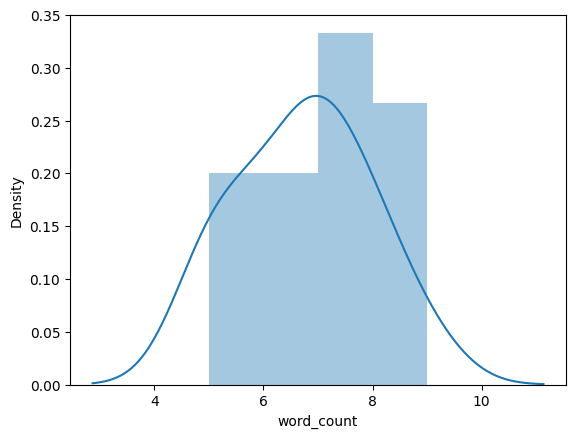

In [ ]:
sns.distplot(df["word_count"])

In [ ]:
spam_word_count=df[df["id"]=="spam"]["word_count"]

In [ ]:
ham_word_count=df[df["id"]=="ham"]["word_count"]

In [ ]:
def estimate_CLT(data,sample_size,no_of_samples):
    mean_lst=[]
    for i in range(no_of_samples):
        smaples=np.random.choice(data,size=sample_size)
        mean_lst.append(np.mean(smaples))
    mean_Array=np.array(mean_lst)
    return np.mean(mean_Array)

In [ ]:
avg_spam_words=estimate_CLT(df["word_count"],30,1000)

In [ ]:
avg_ham_words=estimate_CLT(df["word_count"],30,1000)

In [ ]:
avg_spam_words

np.float64(6.727533333333333)

In [ ]:
avg_ham_words

np.float64(6.733233333333334)

In [ ]:
df["html_count"]=df["text"].str.count("<")

In [ ]:
df.head()

,id,text,char_count,word_count,html_count
0,1,I love Natural Language Processing! It is amaz...,50,8,0
1,2,NLP helps computers understand human language.,46,6,0
2,3,Python is widely used for machine learning and...,50,9,0
3,4,Chatbots are built using NLP techniques.,40,6,0
4,5,"Text preprocessing includes tokenization, stem...",70,7,0


In [ ]:
spam_html_count=df[df["id"]=="spam"]["html_count"]

In [ ]:
ham_html_count=df[df["id"]=="ham"]["html_count"]

In [ ]:
type(spam_html_count)

pandas.core.series.Series

In [ ]:
a1=np.sum(np.array(spam_html_count))

In [ ]:
a2=np.sum(np.array(ham_html_count))

In [ ]:
a1>a2

np.False_

In [ ]:
df["exclamatory_count"]=df["text"].str.count("!")

In [ ]:
spam_ex_count=df[df["id"]=="spam"]["exclamatory_count"]
ham_ex_count=df[df["id"]=="ham"]["exclamatory_count"]

In [ ]:
res=np.sum(np.array(spam_ex_count))>np.sum(np.array(ham_ex_count))

In [ ]:
res

np.False_

In [ ]:
df["count_url"]=df["text"].str.count("http")

In [ ]:
spam_url_count=df[df["id"]=="spam"]["count_url"]
ham_url_count=df[df["id"]=="ham"]["count_url"]

In [ ]:
res1=np.sum(np.array(spam_url_count))>np.sum(np.array(ham_url_count))

In [ ]:
res1

np.False_

# Bivariate Analysis

Text(0.5, 1.0, 'char_count for spam and ham')

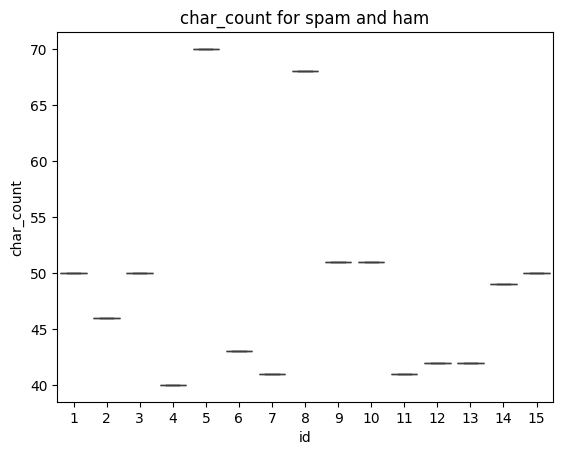

In [ ]:
sns.boxplot(x="id",y="char_count",data=df)
plt.title("char_count for spam and ham")

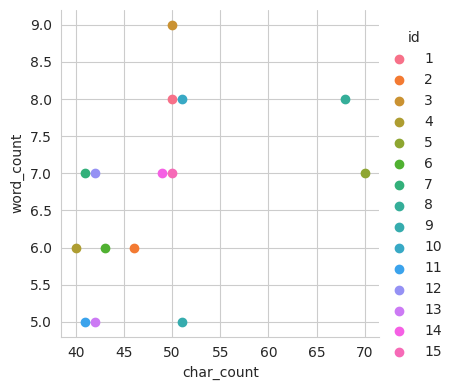

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="id",height=4).map(plt.scatter,"char_count","word_count").add_legend()
plt.show()

# Multivariate Analysis

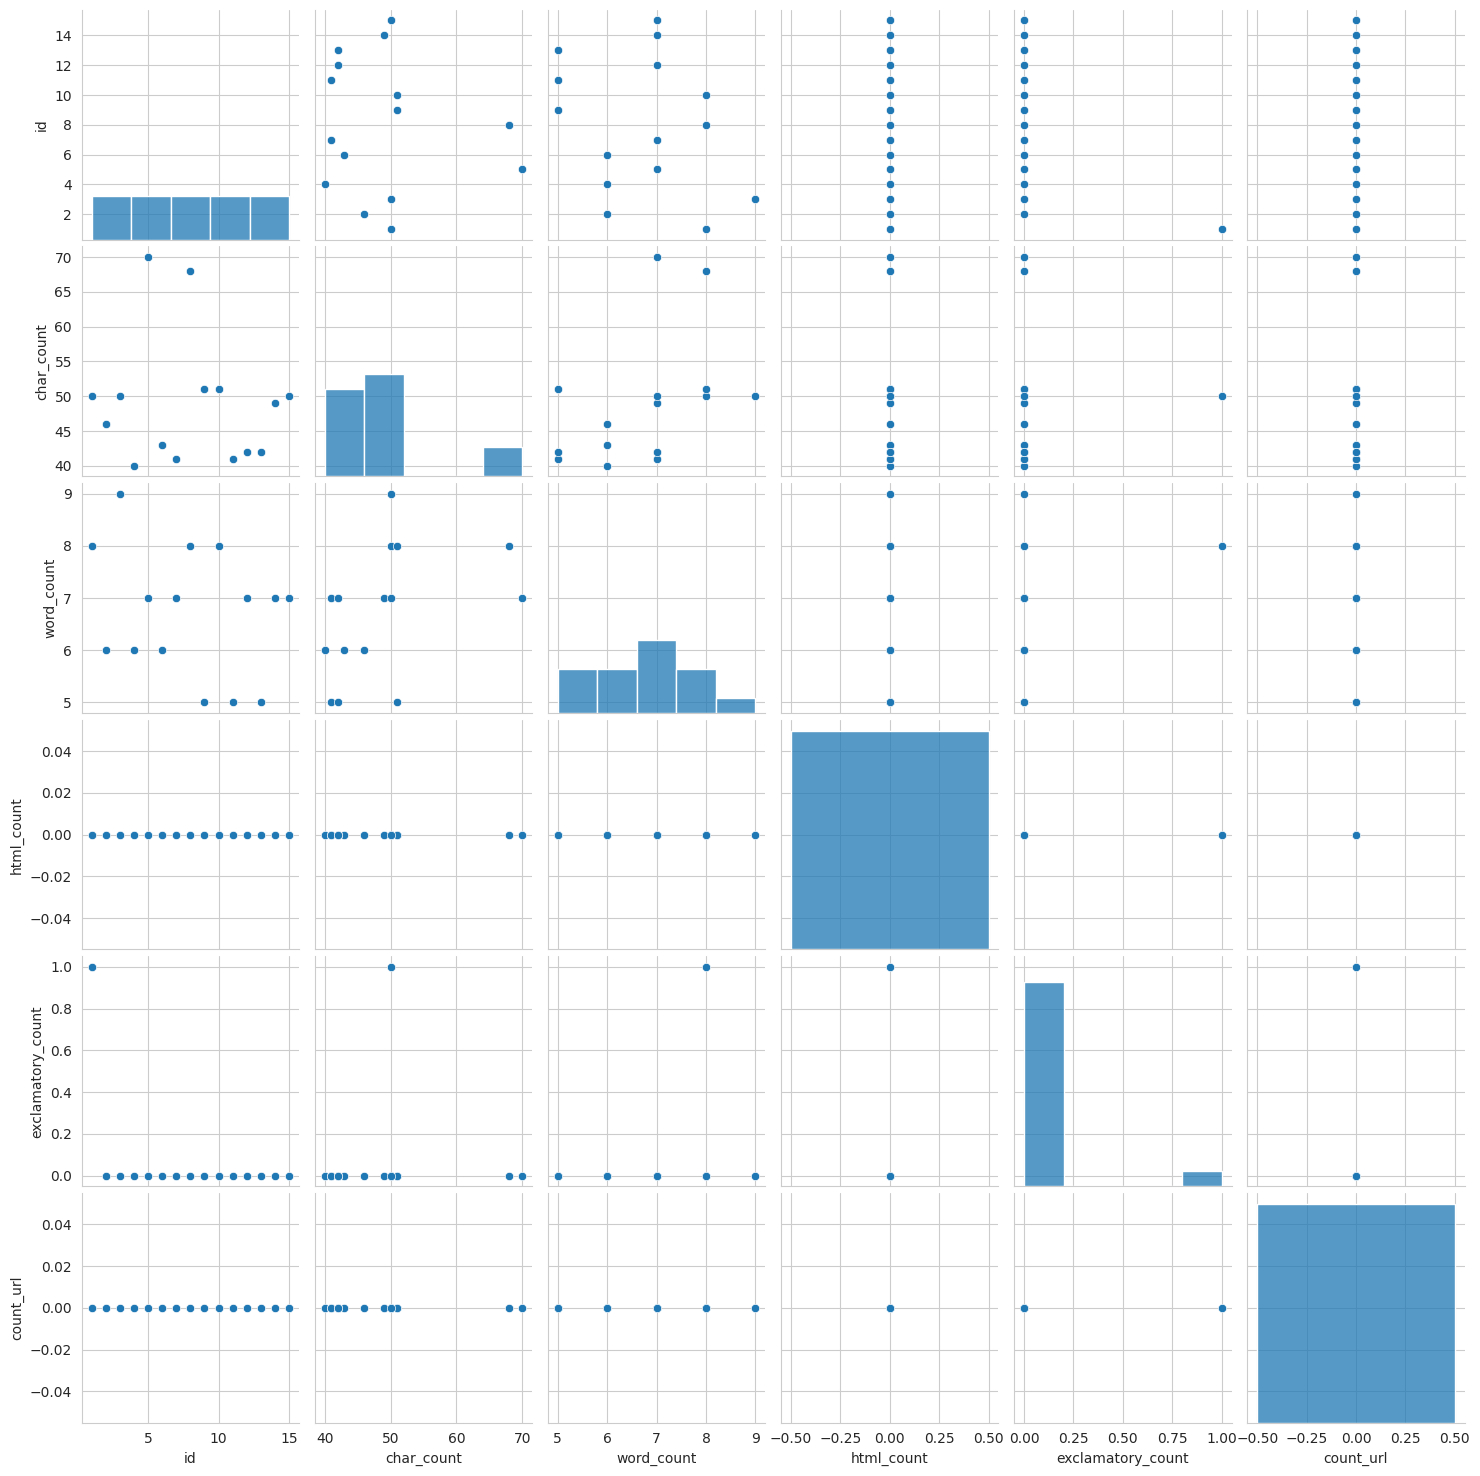

In [ ]:
sns.pairplot(df)
plt.show()